Name : Harshita<br>
Roll Number : 102317003<br>
Lecture Group : L2

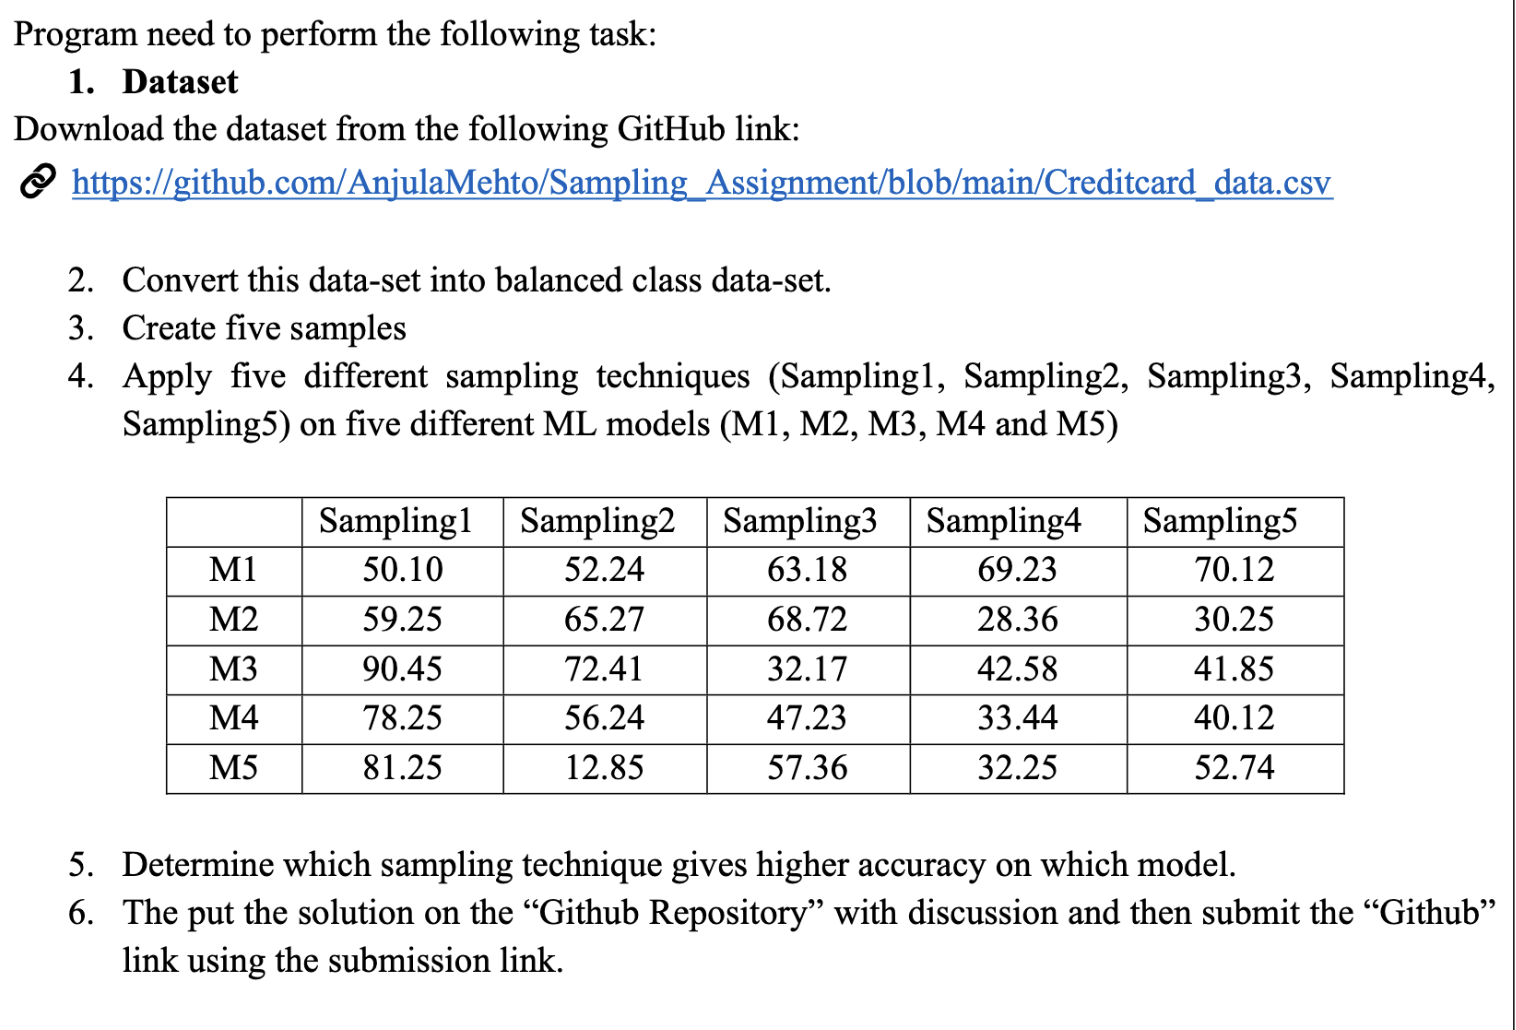

In [2]:
import pandas as pd
import numpy as np

np.random.seed(0)

#1
df = pd.read_csv("/content/Creditcard_data.csv")
df.head(3)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,1
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [22]:
#2
import imblearn
from imblearn.over_sampling import SMOTE
from collections import Counter

print('Shape:',df.shape)

# class count to determine how much imbalanced the data is
class_count_0, class_count_1 = df['Class'].value_counts()
print('Class 0 count :', class_count_0)
print('Class 1 count :', class_count_1)

# Separate class
class_0 = df[df['Class'] == 0]
class_1 = df[df['Class'] == 1]
print('class 0:', class_0.shape)
print('class 1:', class_1.shape)

#undersampling
class_0_under = class_0.sample(150)

test_under = pd.concat([class_0_under, class_1], axis=0)

#synthetic data generation
smote = SMOTE()
x = test_under.drop('Class', axis = 1)
y = test_under['Class']
x_smote, y_smote = smote.fit_resample(x, y)

print('Original dataset shape', Counter(y))
print('Resample dataset shape', Counter(y_smote))

df_smote = pd.DataFrame(x_smote, columns=x.columns)
df_smote['Class'] = y_smote

print('DF Shape:', df_smote.shape)
df_smote.head(3)

# both oversampling and undersampling has been done
# as oversampling from 9 to 763 would really impact the quality of the data.
# Although, even now the quality would be impacted, but much less

Shape: (772, 31)
Class 0 count : 763
Class 1 count : 9
class 0: (763, 31)
class 1: (9, 31)
Original dataset shape Counter({0: 150, 1: 9})
Resample dataset shape Counter({0: 150, 1: 150})
DF Shape: (300, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,112,1.102698,0.103965,0.934479,1.152704,-0.693597,-0.584580,-0.148439,-0.112031,0.196750,...,-0.017211,-0.098781,0.003331,0.394412,0.334208,-0.520700,0.045952,0.048005,54.99,0
1,158,-0.600816,0.922455,-0.135952,-1.259915,2.439824,3.330205,0.087107,0.949659,-0.327932,...,-0.311489,-0.927233,-0.045268,0.979587,0.016423,0.091043,0.371280,0.180187,1.79,0
2,260,1.075229,-0.335339,1.680468,1.192098,-1.270531,0.313498,-0.871025,0.235402,1.315261,...,0.092930,0.815227,-0.054551,0.731149,0.431465,0.580189,0.062528,0.025628,5.46,0


In [26]:
df_smote.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [32]:
# 3
# making 5 different samples

# Simple Random Sampling
sample_frac = 0.7

random_sample = df_smote.sample(frac=sample_frac, random_state=0)
print('Simple Random Sampling:\n')
print(random_sample)

# Stratified Sampling
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(
    n_splits=1,
    test_size=sample_frac,
    random_state=0
)

for x, y in sss.split(df_smote, df_smote['Class']):
    stratified_random_sample = df_smote.iloc[y].sort_index()

print('\nStratified Sampling:\n')
print(stratified_random_sample)

# Cluster Sampling
df_smote['cluster'] = pd.cut(
    df_smote['Time'],
    bins=4,
    labels=False
) + 1

n = [2,4]

def clustering_sampling(df_smote,n):
    df_list=[]
    for i in range(len(n)):
        df1=df_smote[df_smote['cluster']==n[i]]
        df_list.append(df1)
    final_df=pd.concat(df_list, ignore_index=True)

    final_df = final_df.sample(frac=sample_frac, random_state=0)

    return final_df

cluster_sample = clustering_sampling(df_smote,n)
print('\nCluster Sampling:\n')
print(cluster_sample)

# Systematic sampling
def systematic_sampling(df, step):

    indexes = np.arange(0,len(df),step=step)
    systematic_sample = df.iloc[indexes]
    return systematic_sample

step = int(1 / sample_frac)
systematic_sample = systematic_sampling(df_smote, step)
print('\nSystematic Sampling:\n')
print(systematic_sample)

#Bootstrap Sampling
bootstrap_sample = df_smote.sample(
    frac=sample_frac,
    replace=True,
    random_state=0
)

print('\nBootstrap Sampling:\n')
print(bootstrap_sample)



Simple Random Sampling:

     Time        V1        V2        V3        V4        V5        V6  \
208   183  0.085501 -0.690913  0.963793  0.687936  0.892445  0.152127   
188   471 -1.546047 -2.098166  2.164926  1.077653  2.066408  0.361867   
12      0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388   
221   424 -0.740687  0.426791  1.499909  0.170004  0.939549 -0.685369   
239   215 -0.108193 -0.858469  1.103381  0.729916  1.038181  0.193180   
..    ...       ...       ...       ...       ...       ...       ...   
85    557  1.173585  0.250650  0.839631  1.066309 -0.365090 -0.161887   
297   377 -1.084331 -1.702886  1.806849  0.941476  1.772630  0.400069   
141   251  1.071813 -0.249927  0.189825  0.191109 -0.615779 -1.074104   
207   468 -0.985869  1.362273 -0.897703  2.769142 -0.461109 -1.293141   
23     89  0.270725 -1.615317  1.054982  1.661510 -1.737687  0.065894   

           V7        V8        V9  ...       V22       V23       V24  \
208 -0.782791  0.328816  0

In [40]:
# Applying models on samples

# On Random Sample
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

X_random = random_sample.drop('Class', axis=1)
y_random = random_sample['Class']

# Logistic
lr = LogisticRegression(max_iter=1000)
lr.fit(X_random, y_random)
lr_pred_random = lr.predict(X_random)

print("\nLogistic Regression Predictions:")
print(lr_pred_random)

# Decision Tree
dt = DecisionTreeClassifier(random_state=0)
dt.fit(X_random, y_random)
dt_pred_random = dt.predict(X_random)

print("\nDecision Tree Predictions:")
print(dt_pred_random)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(X_random, y_random)
rf_pred_random = rf.predict(X_random)

print("\nRandom Forest Predictions:")
print(rf_pred_random)

# SVM
svm = SVC(kernel='linear')
svm.fit(X_random, y_random)
svm_pred_random = svm.predict(X_random)

print("\nSVM Predictions:")
print(svm_pred_random)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_random, y_random)
knn_pred_random = knn.predict(X_random)

print("\nKNN Predictions:")
print(knn_pred_random)



Logistic Regression Predictions:
[1 1 0 1 1 0 1 1 0 0 1 0 1 1 0 0 1 0 1 1 1 0 0 0 1 0 1 1 1 1 0 0 0 1 1 0 1
 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 1 1 0 0 1 0 1 0 1 1 1 1 0 0 0 1 1 1 0
 0 1 0 0 1 0 0 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 0 1 1 0 1 1 0 1 0 1 1 1 1 1 1
 1 0 0 1 0 1 1 0 0 1 0 1 0 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 0 0 1 0 1 0 0 0
 0 1 1 1 0 1 1 1 0 0 1 0 1 1 0 1 0 0 0 1 0 0 1 1 1 0 1 1 0 1 1 0 0 0 1 0 0
 0 1 0 1 0 1 1 0 1 0 0 0 1 0 1 0 1 0 0 0 0 1 0 1 0]

Decision Tree Predictions:
[1 1 0 1 1 0 1 1 0 0 1 0 1 1 0 0 1 0 1 1 1 0 0 0 1 0 1 1 1 1 0 0 0 0 1 1 1
 1 1 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 0 1 1 0 1 1 0 0 0 1 1 1 1 0 0 0 1 1 1 0
 0 1 0 0 1 0 0 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 1 0 1 1 1 1 1 1
 1 0 0 1 0 1 1 0 0 0 0 0 0 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 0 0 1 0 1 0 0 0
 0 1 1 0 1 1 1 0 0 0 1 0 1 0 0 1 0 0 0 1 0 1 1 0 1 0 1 1 0 1 1 0 0 0 1 1 0
 0 1 0 1 0 1 1 0 1 0 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0]

Random Forest Predictions:
[1 1 0 1 1 0 1 1 0 0 1 0 1 1 0 0 1 0 1 1 1 0 0 0 1 0 1 1

In [41]:
# On Stratified Sample
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

X_stratified = stratified_random_sample.drop('Class', axis=1)
y_stratified = stratified_random_sample['Class']

# Logistic
lr = LogisticRegression(max_iter=1000)
lr.fit(X_stratified, y_stratified)
lr_pred_stratified = lr.predict(X_stratified)

print("\nLogistic Regression Predictions (Stratified):")
print(lr_pred_stratified)

# Decision Tree
dt = DecisionTreeClassifier(random_state=0)
dt.fit(X_stratified, y_stratified)
dt_pred_stratified = dt.predict(X_stratified)

print("\nDecision Tree Predictions (Stratified):")
print(dt_pred_stratified)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(X_stratified, y_stratified)
rf_pred_stratified = rf.predict(X_stratified)

print("\nRandom Forest Predictions (Stratified):")
print(rf_pred_stratified)

# SVM
svm = SVC(kernel='linear')
svm.fit(X_stratified, y_stratified)
svm_pred_stratified = svm.predict(X_stratified)

print("\nSVM Predictions (Stratified):")
print(svm_pred_stratified)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_stratified, y_stratified)
knn_pred_stratified = knn.predict(X_stratified)

print("\nKNN Predictions (Stratified):")
print(knn_pred_stratified)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression Predictions (Stratified):
[0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 1 1 0 0 0 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Decision Tree Predictions (Stratified):
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Random Forest Predictions (Stratified):
[0 0 0 0 0 0 0 0 

In [42]:
# On Cluster Sample
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

X_cluster = cluster_sample.drop('Class', axis=1)
y_cluster = cluster_sample['Class']

# Logistic
lr = LogisticRegression(max_iter=1000)
lr.fit(X_cluster, y_cluster)
lr_pred_cluster = lr.predict(X_cluster)

print("\nLogistic Regression Predictions (Cluster):")
print(lr_pred_cluster)

# Decision Tree
dt = DecisionTreeClassifier(random_state=0)
dt.fit(X_cluster, y_cluster)
dt_pred_cluster = dt.predict(X_cluster)

print("\nDecision Tree Predictions (Cluster):")
print(dt_pred_cluster)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(X_cluster, y_cluster)
rf_pred_cluster = rf.predict(X_cluster)

print("\nRandom Forest Predictions (Cluster):")
print(rf_pred_cluster)

# SVM
svm = SVC(kernel='linear')
svm.fit(X_cluster, y_cluster)
svm_pred_cluster = svm.predict(X_cluster)

print("\nSVM Predictions (Cluster):")
print(svm_pred_cluster)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_cluster, y_cluster)
knn_pred_cluster = knn.predict(X_cluster)

print("\nKNN Predictions (Cluster):")
print(knn_pred_cluster)



Logistic Regression Predictions (Cluster):
[1 0 1 0 1 0 0 0 1 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 0
 0 1 0 1 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 0 1 1 0 1 0 0 0 1 1 1 0 1 1
 1 1 1 1 1 0 1 1 0 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 1 0 0 0 1 1 0 1 1 0 0
 1 1 1 0 1 0 1]

Decision Tree Predictions (Cluster):
[1 0 1 0 1 0 0 0 1 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 0 1 1 1 0 1 1 1 0 1 0
 0 1 0 1 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 0 1 1 0 1 0 0 0 1 1 1 0 0 1
 1 1 1 1 1 0 1 1 0 1 1 0 0 0 1 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 1 1 0 1 1 0 0
 1 1 1 0 1 1 0]

Random Forest Predictions (Cluster):
[1 0 1 0 1 0 0 0 1 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 0 1 1 1 0 1 1 1 0 1 0
 0 1 0 1 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 0 1 1 0 1 0 0 0 1 1 1 0 0 1
 1 1 1 1 1 0 1 1 0 1 1 0 0 0 1 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 1 1 0 1 1 0 0
 1 1 1 0 1 1 0]

SVM Predictions (Cluster):
[1 0 1 0 1 0 0 0 1 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 0
 0 1 0 1 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 0 1 1 0

In [43]:
# On Systematic Sample
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

X_systematic = systematic_sample.drop('Class', axis=1)
y_systematic = systematic_sample['Class']

# Logistic
lr = LogisticRegression(max_iter=1000)
lr.fit(X_systematic, y_systematic)
lr_pred_systematic = lr.predict(X_systematic)

print("\nLogistic Regression Predictions (Systematic):")
print(lr_pred_systematic)

# Decision Tree
dt = DecisionTreeClassifier(random_state=0)
dt.fit(X_systematic, y_systematic)
dt_pred_systematic = dt.predict(X_systematic)

print("\nDecision Tree Predictions (Systematic):")
print(dt_pred_systematic)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(X_systematic, y_systematic)
rf_pred_systematic = rf.predict(X_systematic)

print("\nRandom Forest Predictions (Systematic):")
print(rf_pred_systematic)

# SVM
svm = SVC(kernel='linear')
svm.fit(X_systematic, y_systematic)
svm_pred_systematic = svm.predict(X_systematic)

print("\nSVM Predictions (Systematic):")
print(svm_pred_systematic)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_systematic, y_systematic)
knn_pred_systematic = knn.predict(X_systematic)

print("\nKNN Predictions (Systematic):")
print(knn_pred_systematic)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression Predictions (Systematic):
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 1 0 1 0 1 1 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0
 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1
 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1]

Decision Tree Predictions (Systematic):
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0

In [44]:
# On Bootstrap Sample
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

X_bootstrap = bootstrap_sample.drop('Class', axis=1)
y_bootstrap = bootstrap_sample['Class']

# Logistic
lr = LogisticRegression(max_iter=1000)
lr.fit(X_bootstrap, y_bootstrap)
lr_pred_bootstrap = lr.predict(X_bootstrap)

print("\nLogistic Regression Predictions (Bootstrap):")
print(lr_pred_bootstrap)

# Decision Tree
dt = DecisionTreeClassifier(random_state=0)
dt.fit(X_bootstrap, y_bootstrap)
dt_pred_bootstrap = dt.predict(X_bootstrap)

print("\nDecision Tree Predictions (Bootstrap):")
print(dt_pred_bootstrap)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(X_bootstrap, y_bootstrap)
rf_pred_bootstrap = rf.predict(X_bootstrap)

print("\nRandom Forest Predictions (Bootstrap):")
print(rf_pred_bootstrap)

# SVM
svm = SVC(kernel='linear')
svm.fit(X_bootstrap, y_bootstrap)
svm_pred_bootstrap = svm.predict(X_bootstrap)

print("\nSVM Predictions (Bootstrap):")
print(svm_pred_bootstrap)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_bootstrap, y_bootstrap)
knn_pred_bootstrap = knn.predict(X_bootstrap)

print("\nKNN Predictions (Bootstrap):")
print(knn_pred_bootstrap)



Logistic Regression Predictions (Bootstrap):
[1 0 1 1 1 1 0 1 1 1 1 0 0 0 1 0 0 1 0 1 0 0 1 0 1 1 0 1 1 1 0 0 1 1 0 0 0
 0 1 1 1 1 1 0 1 0 0 0 0 1 1 0 0 0 1 0 1 1 1 0 0 0 0 0 0 1 1 0 0 1 1 0 0 1
 1 1 0 0 1 1 0 1 0 1 1 1 0 0 1 0 0 0 1 0 0 0 1 1 0 1 0 1 0 1 1 0 1 0 1 0 0
 0 1 1 0 1 0 1 1 1 0 1 1 1 1 0 1 1 0 1 1 1 1 0 1 1 1 1 1 0 0 0 1 1 1 0 0 0
 1 0 1 1 1 0 1 0 1 1 0 1 1 0 1 1 1 0 1 1 1 0 0 1 1 1 1 1 1 1 1 0 0 0 0 1 0
 1 0 1 0 1 0 1 1 1 0 0 0 0 1 0 1 1 1 1 1 0 1 0 0 1]

Decision Tree Predictions (Bootstrap):
[1 0 0 1 1 1 0 1 1 1 1 0 0 0 1 0 0 1 0 1 0 0 1 0 1 1 0 1 1 1 0 0 1 1 1 0 0
 0 1 1 1 1 1 0 1 0 0 0 0 1 1 0 0 0 1 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 1 0 0 1
 1 1 0 0 1 1 0 1 0 1 1 1 0 0 1 0 0 0 1 0 0 0 1 0 0 1 0 1 0 1 0 0 1 0 1 0 0
 0 1 0 0 1 0 1 1 1 0 1 0 1 1 0 1 0 0 1 1 1 0 0 1 1 1 1 1 0 0 0 1 0 1 0 0 0
 0 0 1 1 1 0 1 0 1 1 0 0 1 0 1 1 1 0 0 1 1 0 0 1 1 1 1 1 1 1 1 0 0 0 0 1 0
 1 0 1 0 1 0 1 1 1 0 0 0 0 1 0 1 1 1 1 1 0 1 0 0 1]

Random Forest Predictions (Bootstrap):
[1 0 0 1 1 1 0 1 1 1

In [45]:
# Accuracies
from sklearn.metrics import accuracy_score
import pandas as pd

accuracy_df = pd.DataFrame(
    index=[
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'SVM',
        'KNN'
    ],
    columns=[
        'Random',
        'Stratified',
        'Cluster',
        'Systematic',
        'Bootstrap'
    ]
)


y_true_dict = {
    'Random': y_random,
    'Stratified': y_stratified,
    'Cluster': y_cluster,
    'Systematic': y_systematic,
    'Bootstrap': y_bootstrap
}

predictions_dict = {
    'Random': {
        'Logistic Regression': lr_pred_random,
        'Decision Tree': dt_pred_random,
        'Random Forest': rf_pred_random,
        'SVM': svm_pred_random,
        'KNN': knn_pred_random
    },
    'Stratified': {
        'Logistic Regression': lr_pred_stratified,
        'Decision Tree': dt_pred_stratified,
        'Random Forest': rf_pred_stratified,
        'SVM': svm_pred_stratified,
        'KNN': knn_pred_stratified
    },
    'Cluster': {
        'Logistic Regression': lr_pred_cluster,
        'Decision Tree': dt_pred_cluster,
        'Random Forest': rf_pred_cluster,
        'SVM': svm_pred_cluster,
        'KNN': knn_pred_cluster
    },
    'Systematic': {
        'Logistic Regression': lr_pred_systematic,
        'Decision Tree': dt_pred_systematic,
        'Random Forest': rf_pred_systematic,
        'SVM': svm_pred_systematic,
        'KNN': knn_pred_systematic
    },
    'Bootstrap': {
        'Logistic Regression': lr_pred_bootstrap,
        'Decision Tree': dt_pred_bootstrap,
        'Random Forest': rf_pred_bootstrap,
        'SVM': svm_pred_bootstrap,
        'KNN': knn_pred_bootstrap
    }
}


for sample_name in predictions_dict:
    y_true = y_true_dict[sample_name]

    for model_name, y_pred in predictions_dict[sample_name].items():
        accuracy_df.loc[model_name, sample_name] = accuracy_score(y_true, y_pred)

accuracy_df = accuracy_df.astype(float)

print("\nAccuracy Comparison Matrix:\n")
print(accuracy_df)

# From Output : SVM gives highest accuracy on Stratified Sampling


Accuracy Comparison Matrix:

                       Random  Stratified   Cluster  Systematic  Bootstrap
Logistic Regression  0.919048    0.904762  0.957627    0.913333   0.933333
Decision Tree        1.000000    1.000000  1.000000    1.000000   1.000000
Random Forest        1.000000    1.000000  1.000000    1.000000   1.000000
SVM                  0.947619    0.976190  0.974576    0.940000   0.966667
KNN                  0.828571    0.809524  0.754237    0.846667   0.876190
